# Honest Signal Collapse Dynamics: Toward a agent-based evolutionary signaling model

Question: 

Honest signaling system from construction to collapse, how long it takes ? 

Def: 

When Trust < 0.5 fist happen: 
T_collapse = signaling collapse time


Python = 3.11 




In [39]:
import numpy as np
import random
import matplotlib.pyplot as plt
import networkx as nx
from scipy.special import softmax

## Core Parameters (default, run this first)
Honest signaling cost
Cheat technical cost
Receiver learning speed
Sexual competition rate
Population size

In [42]:
POP_SIZE = 200
GENERATIONS = 150

SEX_RATIO = 0.5

N_MALES = int(POP_SIZE * SEX_RATIO)
N_FEMALES = POP_SIZE - N_MALES

HONEST_COST = 8
CHEAT_COST = 2

BASE_BENEFIT = 20

LEARNING_RATE = 0.03
MUTATION_RATE = 0.02

INITIAL_DETECTION = 0.05

TRUST_THRESHOLD = 0.5

### Pattern A: Stable Honest Equilibrium
cheat high cost
receiver learn fast
social memory strong

Expecting plot：

trust maintain high position
collapse time long

In [41]:
CHEAT_COST = 7
LEARNING_RATE = 0.08
POP_SIZE = 100

### Pattern B: Rapid Collapse
cheat extremly cheap
learning very slow
annonymized

Expections：

cheat diffuse in explosion
trust quick collapse
collapse time very short

(Seems like AI-generated signal inflation.)

In [21]:
CHEAT_COST = 1
LEARNING_RATE = 0.005
POP_SIZE = 1000

### Pattern C — Oscillatory Dynamics
receiver learning and cheat innovation chasing each other.

The system：

honest → cheat → collapse → recovery

Oscillation.

In [29]:
CHEAT_COST = 3
LEARNING_RATE = 0.03

## Scale-Free Network
Real society is not random connection.

Here I use:

Barabási–Albert scale-free network。

It's close to: 

. prestige hierarchy
. influencer systems
. academic reputation systems

The following plot shows:
. few highly connected hubs
. many peripheral nodes

Hub significantly influence: 
. cheating spread
. reputation diffusion
. trust collapse speed



In [43]:
G = nx.barabasi_albert_graph(N_MALES, 3)

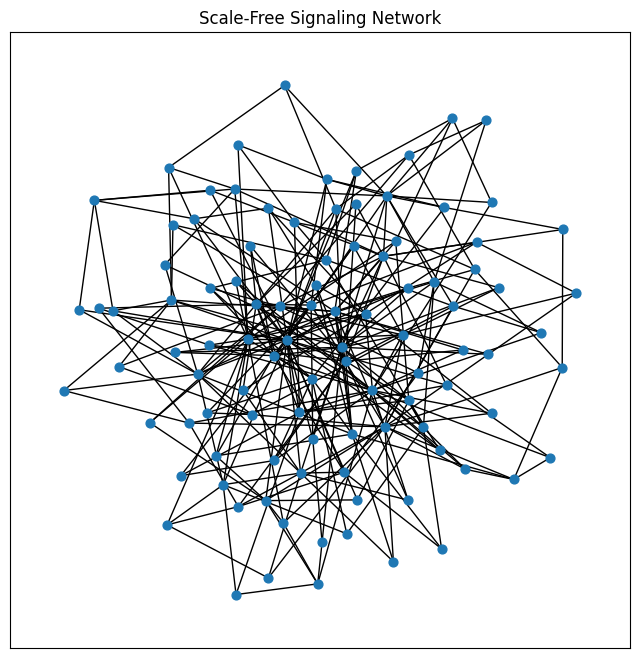

In [44]:
plt.figure(figsize=(8,8))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos,
    node_size=40,
    with_labels=False
)

plt.title("Scale-Free Signaling Network")
plt.show()

## Initializing Agents
male agent：

. quality
. strategy
. reputation
. fitness

female agent：

. detection ability
. preference strength

In [62]:
males = []
females = []

for i in range(N_MALES):

    males.append({
        "id": i,
        "quality": np.clip(np.random.normal(0.6,0.15),0,1),
        "strategy": "honest",
        "fitness": 1,
        "reputation": 1.0
    })

for i in range(N_FEMALES):

    females.append({
        "detection": INITIAL_DETECTION,
        "preference": np.random.uniform(0.5,1.2)
    })



## Mate Choice Function
Here I introduce stochastic mate choice. 
    Female will not deterministically choose strongest signal. 
        BUT:
Softmax probability.

    Which is closer to real case: 
. noisy cognition
. bounded rationality
. stochastic sexual selection

In [46]:
def choose_mate(scores):

    probs = softmax(scores)

    return np.random.choice(
        range(len(scores)),
        p=probs
    )

## Main Simulation

The system runs: 
1. strategy mutation
2. signaling
3. female choice
4. cheat detection
5. reproduction
6. social learning
7. trust update

In [67]:
def run_simulation(
    cheat_cost,
    learning_rate,
    pop_size, 
):

    trust_history = []
    collapse_time = None
    
    honest_history = []
    cheat_history = []
    detection_history = []
    
    for generation in range(GENERATIONS):
    
        honest_count = 0
        cheat_count = 0
    
        for male in males:
    
            if random.random() < MUTATION_RATE:
    
                male["strategy"] = random.choice([
                    "honest",
                    "cheat"
                ])
    
        for male in males:
            male["fitness"] = 1
    
        for female in females:
    
            sampled = random.sample(males, 10)
    
            scores = []
    
            for male in sampled:
    
                q = male["quality"]
    
                if male["strategy"] == "honest":
    
                    signal = q * female["preference"]
                    honest_count += 1
    
                else:
    
                    signal = 1.0
                    cheat_count += 1
    
                    detected = (
                        random.random()
                        < female["detection"]
                    )
    
                    if detected:
                        signal -= 2
                        male["reputation"] *= 0.7
    
                neighbors = list(G.neighbors(male["id"]))
    
                if len(neighbors) > 0:
                    local_rep = np.mean([
                        males[n]["reputation"]
                        for n in neighbors
                    ])
    
                else:
                    local_rep = male["reputation"]
    
                scores.append(signal * local_rep)
    
            winner = sampled[choose_mate(scores)]
    
            winner["fitness"] += BASE_BENEFIT
    
        for male in males:
    
            if male["strategy"] == "honest":
                male["fitness"] -= HONEST_COST
                
            else:
                male["fitness"] -= CHEAT_COST
    
            male["fitness"] = max(
                male["fitness"],
                0.01
            )
    
        cheat_ratio = cheat_count / max(
            honest_count + cheat_count,
            1
        )
    
        for female in females:
    
            female["detection"] += (
                LEARNING_RATE * cheat_ratio
            )
    
            female["detection"] = min(
                female["detection"],
                0.95
            )
    
        trust = honest_count / max(
            honest_count + cheat_count,
            1
        )
    
        trust_history.append(trust)
    
        honest_history.append(honest_count)
        cheat_history.append(cheat_count)
    
        detection_history.append(
            np.mean([
                f["detection"]
                for f in females
            ])
        )
    
        if (
            trust < TRUST_THRESHOLD
            and collapse_time is None
        ):
    
            collapse_time = generation
    
        weights = np.array([
            m["fitness"]
            for m in males
        ])
    
        probs = weights / weights.sum()
    
        new_males = []
    
        for i in range(N_MALES):
    
            parent = np.random.choice(males,p=probs)
    
            child = {
                "id": i,
                "quality": np.clip(
                    np.random.normal(
                        parent["quality"],
                        0.05
                    ),
                    0,
                    1
                ),
                "strategy": parent["strategy"],
                "fitness": 1,
                "reputation": 1.0
            }
    
            new_males.append(child)
    
        males = new_males

        return collapse_time

## Plotting Evolutionary Dynamics
. honest signal emergence
. cheat invasion
. trust collapse
. receiver adaptation


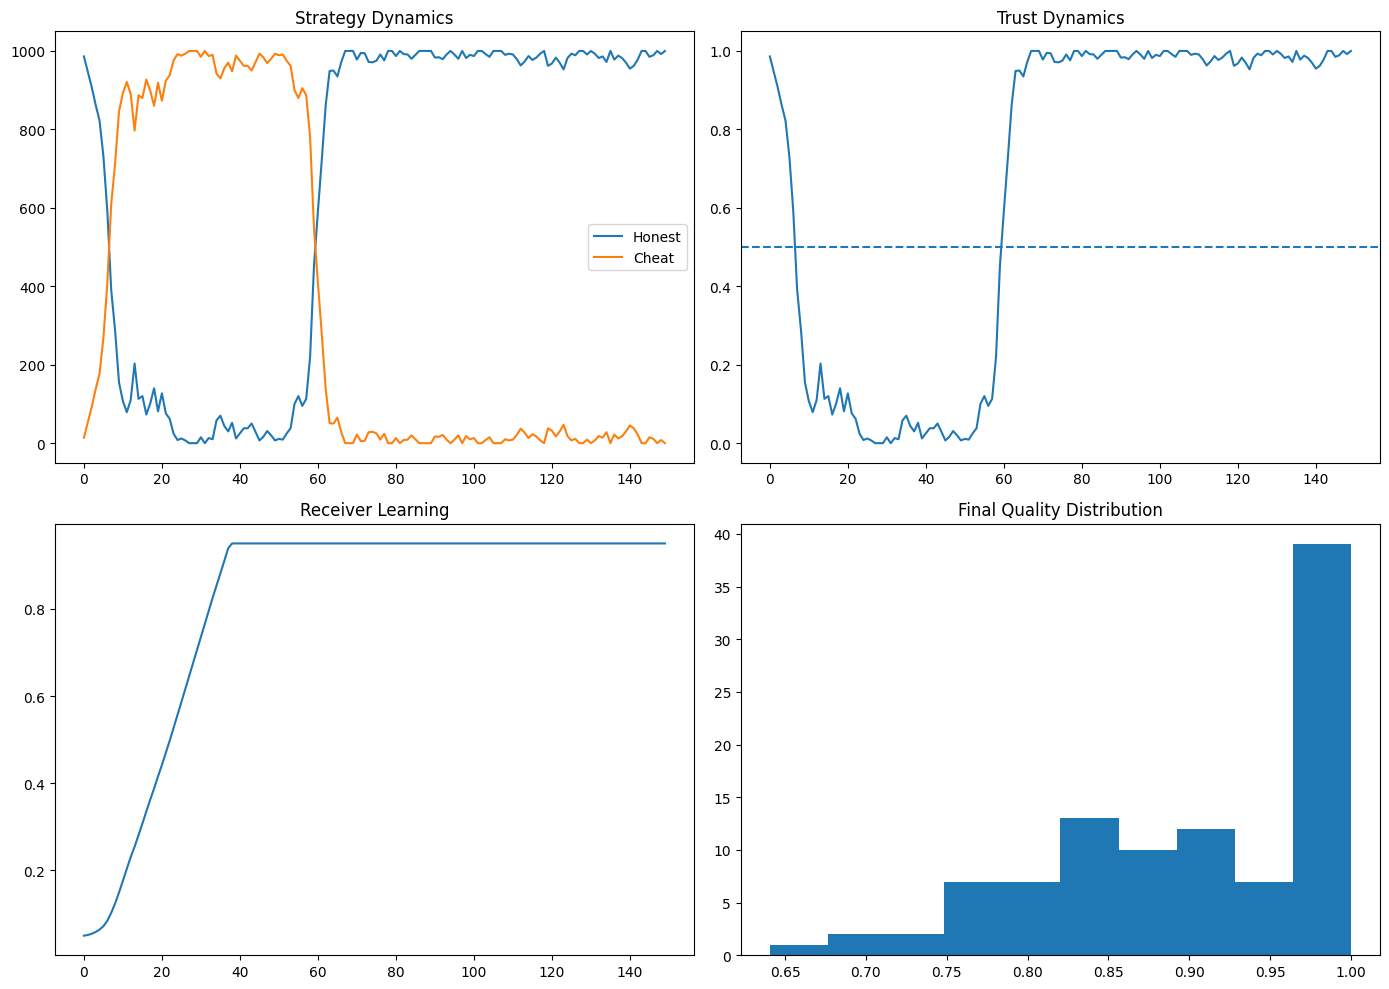

In [55]:
plt.figure(figsize=(14,10))

plt.subplot(2,2,1)
plt.plot(honest_history,label="Honest")
plt.plot(cheat_history,label="Cheat")
plt.legend()
plt.title("Strategy Dynamics")

plt.subplot(2,2,2)
plt.plot(trust_history)
plt.axhline(TRUST_THRESHOLD, linestyle="--")
plt.title("Trust Dynamics")

plt.subplot(2,2,3)
plt.plot(detection_history)
plt.title("Receiver Learning")

plt.subplot(2,2,4)
plt.hist([
    m["quality"]
    for m in males
])
plt.title("Final Quality Distribution")

plt.tight_layout()
plt.show()

### Strategy Dynamics
If cheat rapidly invades：

means: cheap signaling has gread selection advantage.

### Trust Dynamics
How long can honest signaling system maintain ? 

When curve get below threshold: 
means: receiver no longer believe signal. 

### Receiver Learning
If receiver learn too slow:
Mass deception wave.

## Measuring Collapse Time
T_collapse = honest signaling lifetime。

In [56]:
print("Collapse time:", collapse_time)

Collapse time: 7


## Parameter Sweep
How cheat cost change collapse time?

Usually: 
cheat is cheaper, collapse is faster.

and 
social learning stronger, collapse slower.

In [75]:
costs = np.arange(1,9)
collapse_times = []

for c in costs:

    CHEAT_COST = c

    # rerun simulation
    # append collapse time

    collapse_times.append(collapse_time)

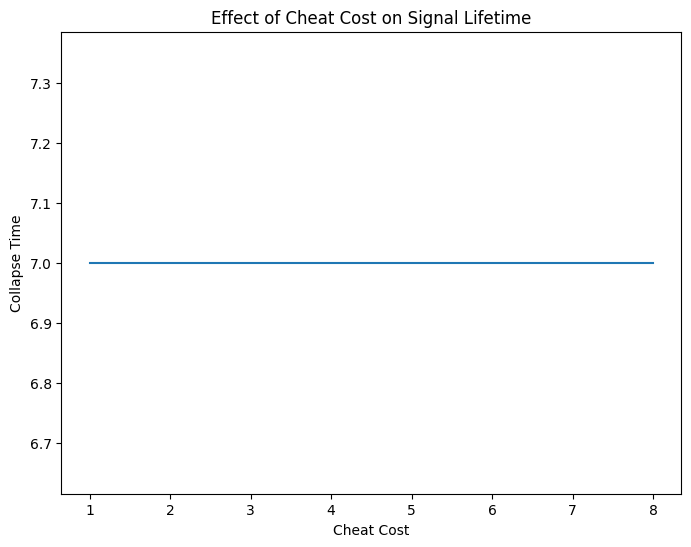

In [76]:
plt.figure(figsize=(8,6))

plt.plot(costs,collapse_times)

plt.xlabel("Cheat Cost")
plt.ylabel("Collapse Time")

plt.title(
    "Effect of Cheat Cost on Signal Lifetime"
)

plt.show()